<a href="https://colab.research.google.com/github/mohamedzaghloul-lab638/rdkit-tips-and-tricks-/blob/main/MCS_in_rdkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install rdkit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 16.3 MB/s eta 0:00:00


In [2]:
from rdkit import Chem
from rdkit.Chem import AllChem , Draw

In [5]:
#MCS maximum common subst  >> most common substructures between set of molecules

from rdkit.Chem import rdFMCS
mol1=Chem.MolFromSmiles('C1=CC=C(C=C1)O') # phenol
m1=mol1.GetNumAtoms()
print(m1)
mol2=Chem.MolFromSmiles('C1=CC=CC=C1') # benzene
mol3=Chem.MolFromSmiles('CC1=CC=CC=C1') # toluene
rd=rdFMCS.FindMCS([mol1,mol2, mol3])
nat=rd.numAtoms
nbo=rd.numBonds
smst=rd.smartsString
print(smst)
print(nat)
print(nbo)

7
[#6]1:[#6]:[#6]:[#6]:[#6]:[#6]:1
6
6


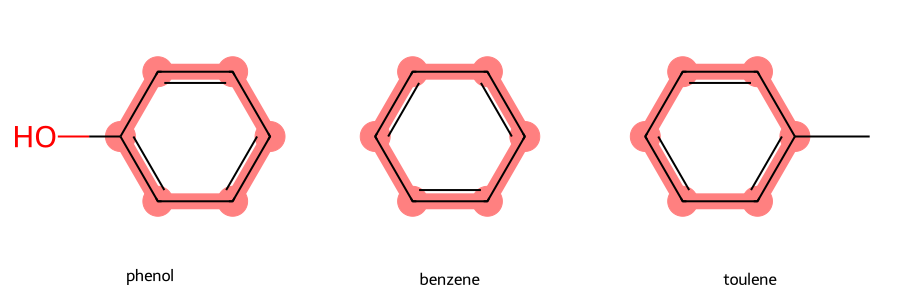

In [4]:
AllChem.Compute2DCoords(mol1)
AllChem.Compute2DCoords(mol2)
AllChem.Compute2DCoords(mol3)
patt=Chem.MolFromSmarts(smst)
match1=mol1.GetSubstructMatch(patt)
match2=mol2.GetSubstructMatch(patt)
match3=mol3.GetSubstructMatch(patt)

Draw.MolsToGridImage([mol1 , mol2 , mol3] , legends=['phenol','benzene' , 'toulene'] , highlightAtomLists=[match1 , match2 , match3] , subImgSize=(300,300) , molsPerRow=3)